# Prepare data

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
from IPython.display import display

In [2]:
# read the new dataframe
crime_count_df = pd.read_csv("crime_count_df.csv")
crime_count_df['crime date'] = pd.to_datetime(crime_count_df['crime date'])  # convert to datetime
crime_count_df.set_index('crime date', inplace=True)           # make date the index
crime_count_df = crime_count_df.asfreq('D')                              # ensure daily frequency

# Check for missing dates (NaNs may appear if any days are missing)
crime_count_df = crime_count_df.fillna(0)
warnings.filterwarnings('ignore')

<Axes: xlabel='crime date'>

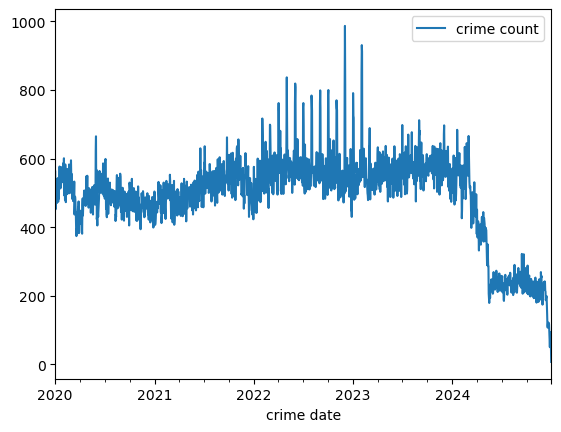

In [3]:
crime_count_df.plot()

<Axes: xlabel='crime date'>

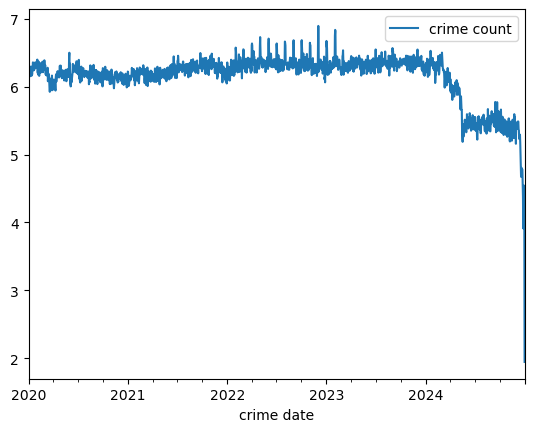

In [4]:
copy = np.log(crime_count_df)
copy.plot()

## Split Dataset

In [5]:
crime_count_df = crime_count_df.reset_index()

# the train dataset is from the beginning of January 2020 until the beginning of October 2024
train = crime_count_df[crime_count_df['crime date'] < '2024-10-01']
test = crime_count_df[crime_count_df['crime date'] >= '2024-10-01']


In [6]:
train.set_index('crime date', inplace=True)
test.set_index('crime date', inplace=True)

## ACF and PACF plot

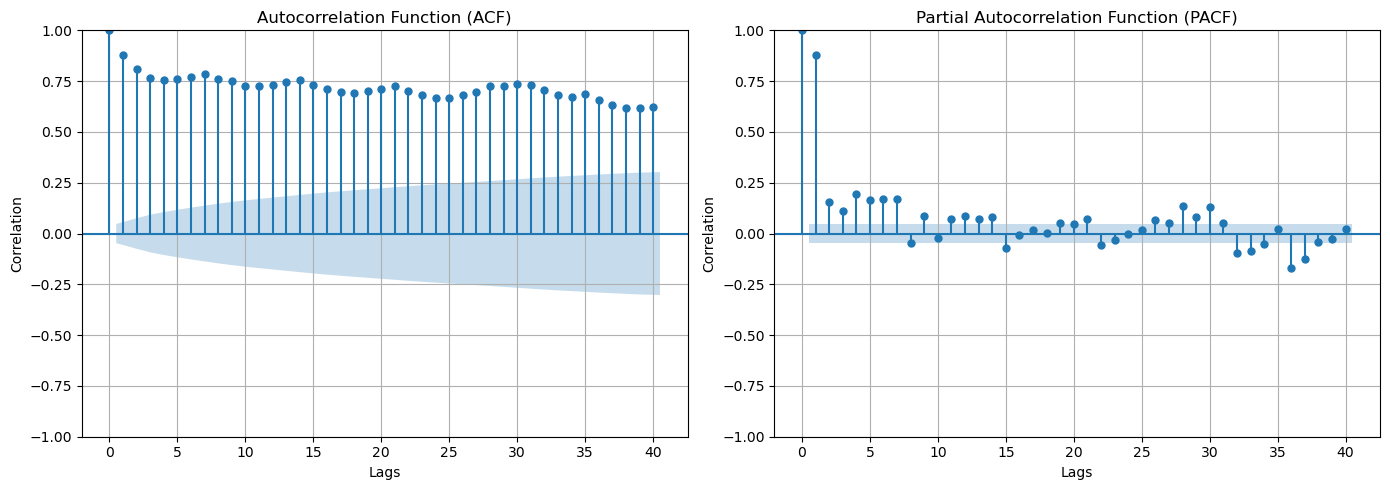

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ACF
plot_acf(train, lags=40, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Correlation")
axes[0].grid(True)

# PACF
plot_pacf(train, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF)")
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Correlation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Transform to stationary

<Axes: xlabel='crime date'>

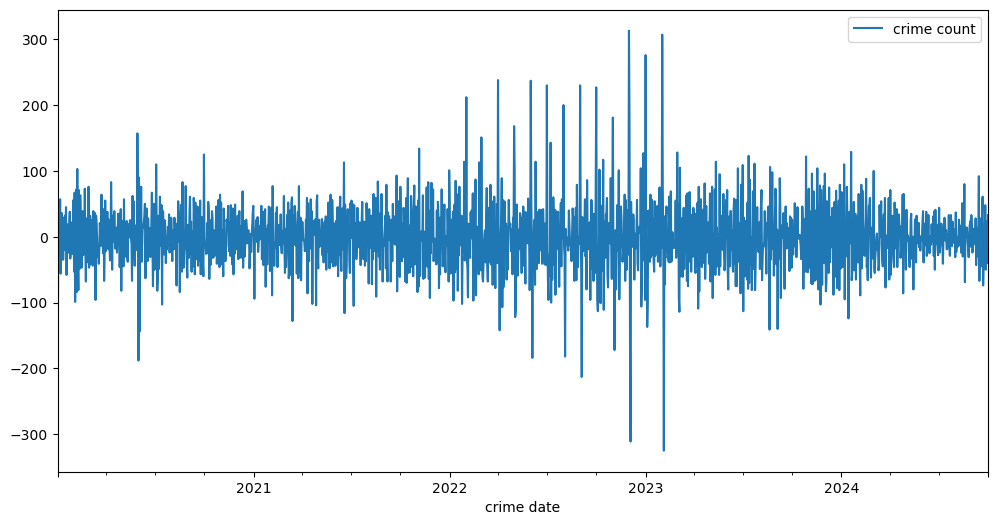

In [8]:
train_diff = train.diff().dropna()
train_diff.plot(figsize=(12, 6))

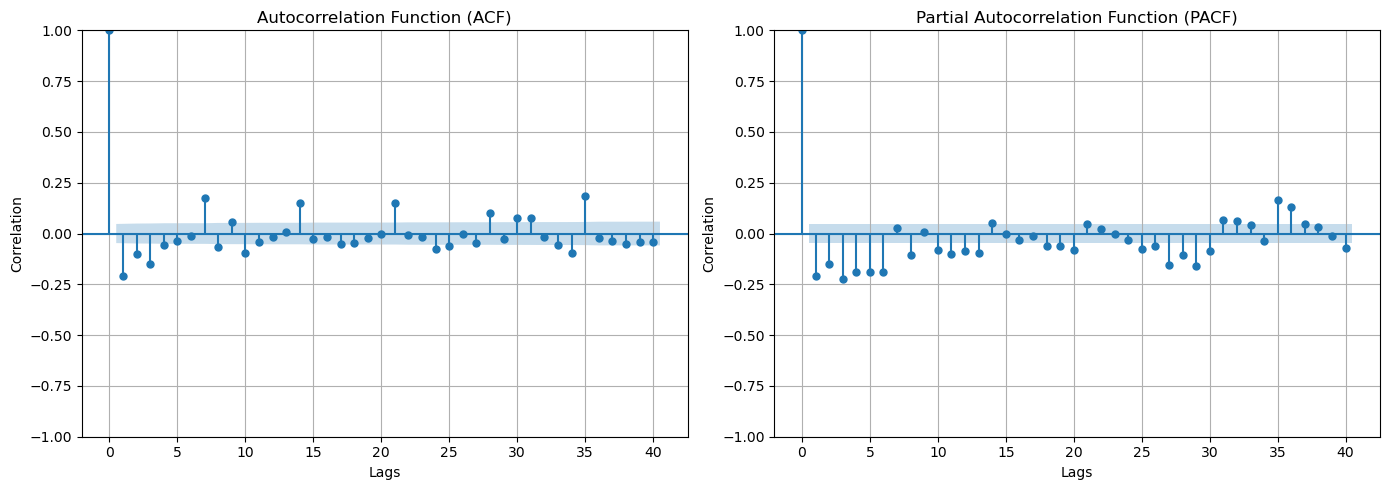

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ACF
plot_acf(train_diff, lags=40, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("Correlation")
axes[0].grid(True)

# PACF
plot_pacf(train_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF)")
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("Correlation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## AIC Function

In [10]:
#Finding the best value for ARIMA
import statsmodels.api as sm
import itertools
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

p=d=q=range(0,8)
pdq = list(itertools.product(p,d,q))

results = []


for param in pdq:
    try:
        model_arima = sm.tsa.arima.ARIMA(train,order=param)
        model_arima_fit = model_arima.fit()
        aic_value = model_arima_fit.aic
        results.append((param, aic_value))
        print(param,model_arima_fit.aic)
    except:
        continue




(0, 0, 0) 21081.993857157006
(0, 0, 1) 19828.354715308626
(0, 0, 2) 19214.559350057363
(0, 0, 3) 18996.068936040778
(0, 0, 4) 18818.56227747631
(0, 0, 5) 18732.64149553802
(0, 0, 6) 18725.88882208789
(0, 0, 7) 18629.647093652573
(0, 1, 0) 18555.874975155857
(0, 1, 1) 18418.384323000093
(0, 1, 2) 18215.752414388106
(0, 1, 3) 18144.44433178294
(0, 1, 4) 18146.06683129335
(0, 1, 5) 18148.05021972762
(0, 1, 6) 18146.697907632857
(0, 1, 7) 18134.319803809696
(0, 2, 0) 20077.731034374985
(0, 2, 1) 18555.521581777357
(0, 2, 2) 18419.22235921469
(0, 2, 3) 18218.15409722447
(0, 2, 4) 18145.315391734417
(0, 2, 5) 18148.583776155105
(0, 2, 6) 18150.60276948976
(0, 2, 7) 18149.32421853979
(0, 3, 0) 22019.006237772828
(0, 3, 1) 20076.228008659644
(0, 3, 2) 18576.63972165282
(0, 3, 3) 18436.57729245434
(0, 3, 4) 18248.429860480242
(0, 3, 5) 18165.720974001444
(0, 3, 6) 18172.99731917007
(0, 3, 7) 18179.542386047826
(0, 4, 0) 24121.58897891292
(0, 4, 1) 22015.18499260545
(0, 4, 2) 20080.035423345642


In [11]:
# Sort by AIC (ascending) and pick the best 10
top_10 = sorted(results, key=lambda x: x[1])[:10]

print("\nTop 10 parameter sets with lowest AIC:")
for param, aic in top_10:
    print(f"ARIMA{param} - AIC: {aic}")


Top 10 parameter sets with lowest AIC:
ARIMA(5, 6, 2) - AIC: 16.0
ARIMA(7, 7, 2) - AIC: 20.0
ARIMA(6, 7, 5) - AIC: 24.0
ARIMA(0, 6, 7) - AIC: 1984.972202973537
ARIMA(2, 7, 4) - AIC: 3335.423729870711
ARIMA(3, 7, 7) - AIC: 3489.930971890638
ARIMA(0, 5, 6) - AIC: 4143.28137921888
ARIMA(0, 5, 4) - AIC: 5249.184348592478
ARIMA(0, 7, 5) - AIC: 6321.467687261666
ARIMA(1, 6, 7) - AIC: 6690.089107225455


# Model Planning/Building

## Model 1: (4, 3, 2)

In [12]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")
# ====== 1. Fit ARIMA ======
model = ARIMA(train, order=(4, 3, 2))  # no seasonal_order for ARIMA
results = model.fit()
print(results.summary())


                               SARIMAX Results                                
Dep. Variable:            crime count   No. Observations:                 1735
Model:                 ARIMA(4, 3, 2)   Log Likelihood               -9166.095
Date:                Wed, 20 Aug 2025   AIC                          18346.190
Time:                        13:22:18   BIC                          18384.389
Sample:                    01-01-2020   HQIC                         18360.318
                         - 09-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3011      0.016    -18.797      0.000      -0.332      -0.270
ar.L2         -0.2262      0.019    -11.709      0.000      -0.264      -0.188
ar.L3         -0.2575      0.014    -17.948      0.0

In [13]:
# ====== 2. Forecast ======
forecast_steps = len(test)
forecast_obj = results.get_forecast(steps=forecast_steps)
forecast_df = forecast_obj.conf_int()
forecast_df['Prediction'] = forecast_obj.predicted_mean
forecast_df.index = test.index  # align with actual test dates


In [14]:
# ====== 3. Evaluate ======
mae = mean_absolute_error(test, forecast_df['Prediction'])
rmse = np.sqrt(mean_squared_error(test, forecast_df['Prediction']))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")



MAE: 61.21, RMSE: 77.89


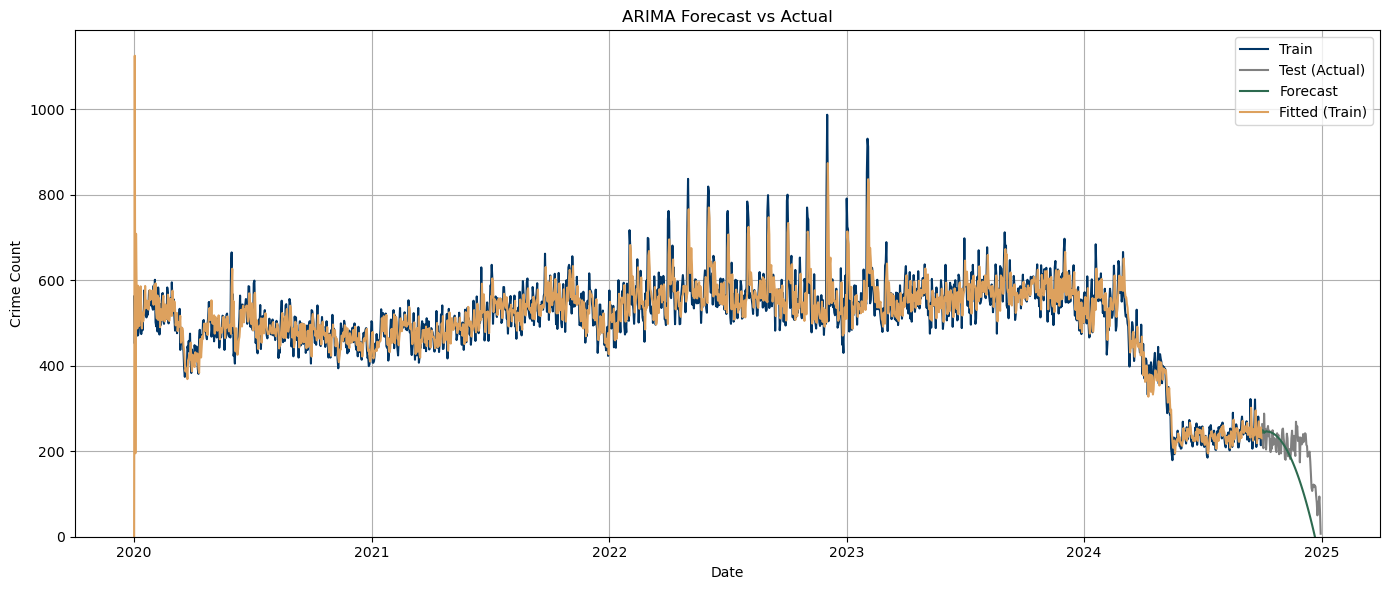

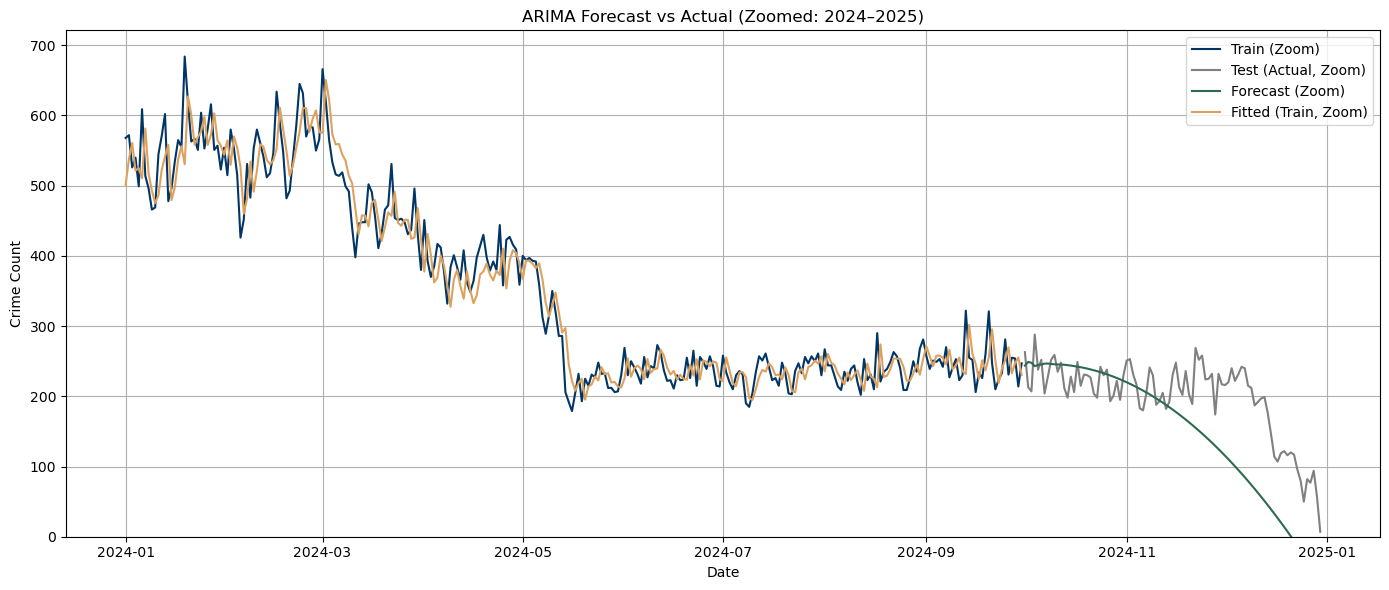

In [15]:
# ====== 4. Plot ======
plt.figure(figsize=(14, 6))

# Train and Test
plt.plot(train.index, train, label='Train', color='#003566')
plt.plot(test.index, test, label='Test (Actual)', color='gray')

# Forecast
plt.plot(forecast_df.index, forecast_df['Prediction'], label='Forecast', color='#2d6a4f')


# Fitted values (train only)
plt.plot(train.index, results.fittedvalues, label='Fitted (Train)', color='#dda15e')

# Styling
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 6))

# Only keep values from 2024 onwards
zoom_start = '2024-01-01'
train_zoom = train[train.index >= zoom_start]
test_zoom = test[test.index >= zoom_start]
forecast_zoom = forecast_df[forecast_df.index >= zoom_start]

plt.plot(train_zoom.index, train_zoom, label='Train (Zoom)', color='#003566')
plt.plot(test_zoom.index, test_zoom, label='Test (Actual, Zoom)', color='gray')
plt.plot(forecast_zoom.index, forecast_zoom['Prediction'], label='Forecast (Zoom)', color='#2d6a4f')
plt.plot(train_zoom.index, results.fittedvalues[train_zoom.index], label='Fitted (Train, Zoom)', color='#dda15e')

plt.title('ARIMA Forecast vs Actual (Zoomed: 2024–2025)')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

## Model 2: (4, 3, 3)

In [16]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")
# ====== 1. Fit ARIMA ======
model = ARIMA(train, order=(4, 3, 3))  # no seasonal_order for ARIMA
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:            crime count   No. Observations:                 1735
Model:                 ARIMA(4, 3, 3)   Log Likelihood               -9176.690
Date:                Wed, 20 Aug 2025   AIC                          18369.379
Time:                        13:22:23   BIC                          18413.036
Sample:                    01-01-2020   HQIC                         18385.526
                         - 09-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2769      0.018    -71.103      0.000      -1.312      -1.242
ar.L2         -0.4825      0.032    -15.077      0.000      -0.545      -0.420
ar.L3         -0.4284      0.028    -15.518      0.0

In [17]:
# ====== 2. Forecast ======
forecast_steps = len(test)
forecast_obj = results.get_forecast(steps=forecast_steps)
forecast_df = forecast_obj.conf_int()
forecast_df['Prediction'] = forecast_obj.predicted_mean
forecast_df.index = test.index  # align with actual test dates

In [18]:
# ====== 3. Evaluate ======
mae = mean_absolute_error(test, forecast_df['Prediction'])
rmse = np.sqrt(mean_squared_error(test, forecast_df['Prediction']))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 34.20, RMSE: 48.96


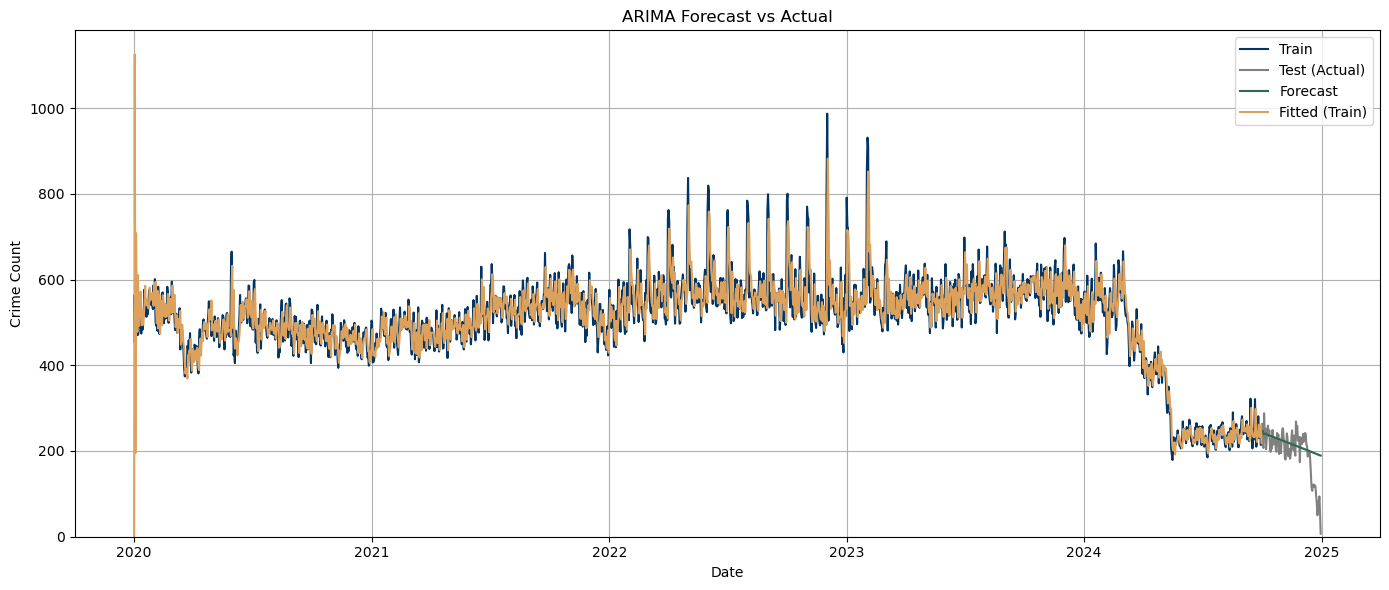

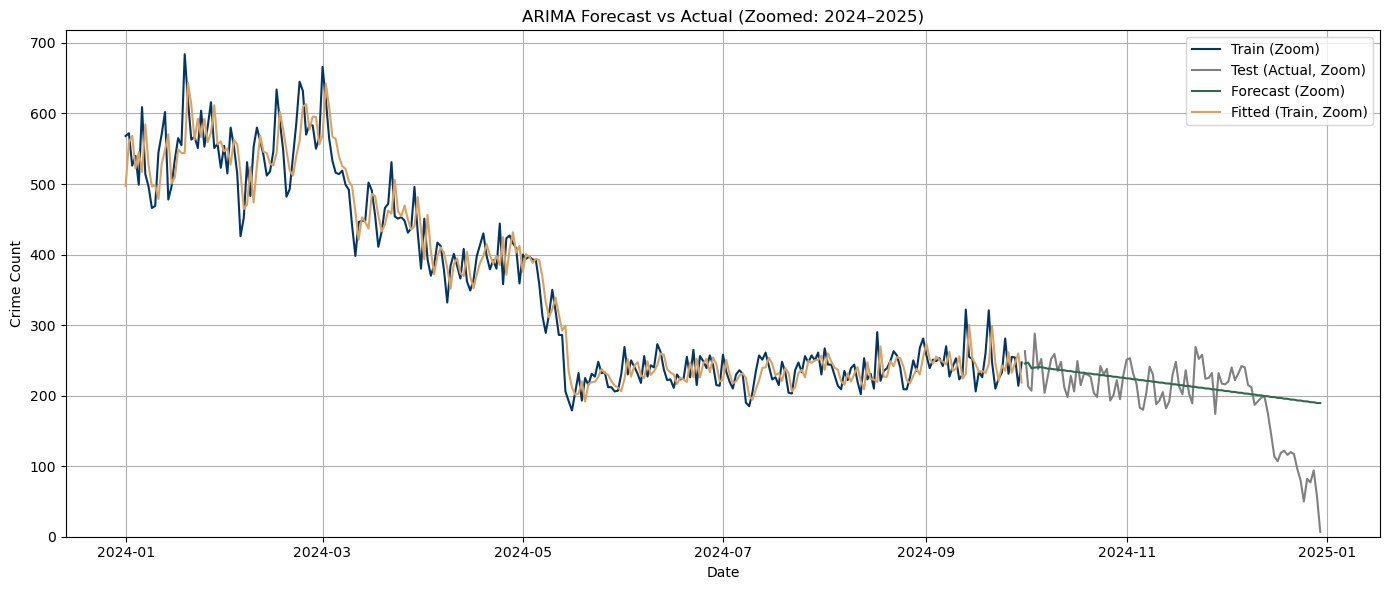

In [19]:
# ====== 4. Plot ======
plt.figure(figsize=(14, 6))

# Train and Test
plt.plot(train.index, train, label='Train', color='#003566')
plt.plot(test.index, test, label='Test (Actual)', color='gray')

# Forecast
plt.plot(forecast_df.index, forecast_df['Prediction'], label='Forecast', color='#2d6a4f')


# Fitted values (train only)
plt.plot(train.index, results.fittedvalues, label='Fitted (Train)', color='#dda15e')

# Styling
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 6))

# Only keep values from 2024 onwards
zoom_start = '2024-01-01'
train_zoom = train[train.index >= zoom_start]
test_zoom = test[test.index >= zoom_start]
forecast_zoom = forecast_df[forecast_df.index >= zoom_start]

plt.plot(train_zoom.index, train_zoom, label='Train (Zoom)', color='#003566')
plt.plot(test_zoom.index, test_zoom, label='Test (Actual, Zoom)', color='gray')
plt.plot(forecast_zoom.index, forecast_zoom['Prediction'], label='Forecast (Zoom)', color='#2d6a4f')
plt.plot(train_zoom.index, results.fittedvalues[train_zoom.index], label='Fitted (Train, Zoom)', color='#dda15e')

plt.title('ARIMA Forecast vs Actual (Zoomed: 2024–2025)')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()